In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/industrial-ai-project/MetroPT3(AirCompressor).csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.drop(columns=['Unnamed: 0'])

# Sensor Behavior Around Failure #1 (2020-04-18)

In [ ]:
failure_1_start = pd.to_datetime("2020-04-18 00:00:00")
window_start = failure_1_start - pd.Timedelta(days=2)
window_end = failure_1_start + pd.Timedelta(hours=6)
failure_1_window = df[
    (df['timestamp'] >= window_start) &
    (df['timestamp'] <= window_end)
]
print(failure_1_window.shape)

(16453, 16)


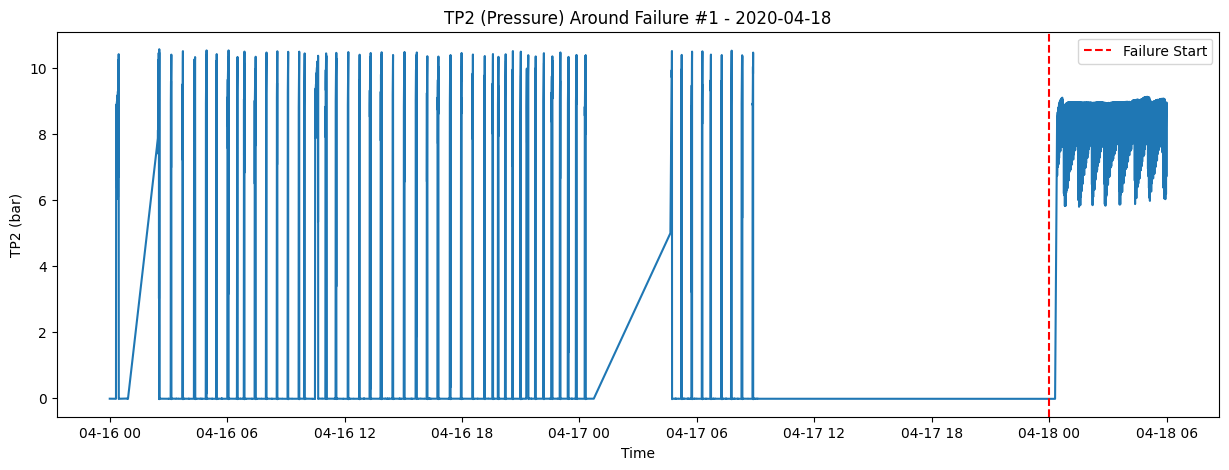

In [ ]:
import matplotlib.pyplot as plt

# Plot TP2 (pressure) over time, for the window around failure #1
plt.figure(figsize=(15, 5))
plt.plot(failure_1_window['timestamp'], failure_1_window['TP2'])

# Mark the exact failure start time with a vertical red line
plt.axvline(x=failure_1_start, color='red', linestyle='--', label='Failure Start')

plt.title('TP2 (Pressure) Around Failure #1 - 2020-04-18')
plt.xlabel('Time')
plt.ylabel('TP2 (bar)')
plt.legend()
plt.show()

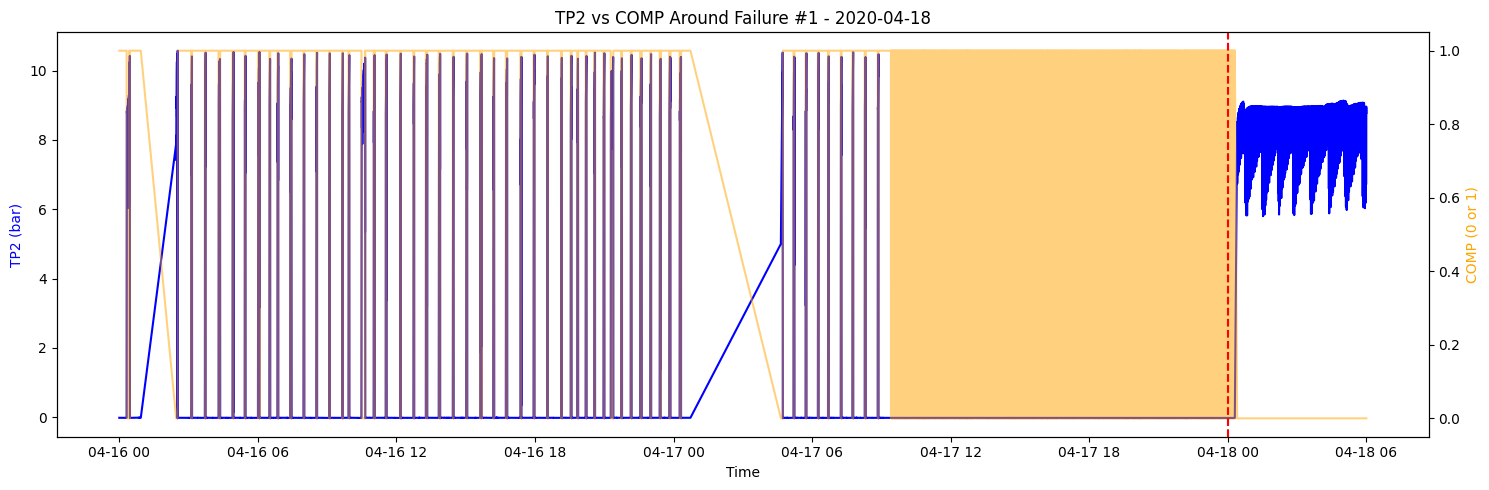

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 5))

# Plot TP2 on the left axis (blue)
ax1.plot(failure_1_window['timestamp'], failure_1_window['TP2'], color='blue', label='TP2 (Pressure)')
ax1.set_xlabel('Time')
ax1.set_ylabel('TP2 (bar)', color='blue')

# Create a second y-axis sharing the same x-axis, for COMP
ax2 = ax1.twinx()
ax2.plot(failure_1_window['timestamp'], failure_1_window['COMP'], color='orange', alpha=0.5, label='COMP (Compressor ON/OFF)')
ax2.set_ylabel('COMP (0 or 1)', color='orange')

plt.axvline(x=failure_1_start, color='red', linestyle='--', label='Failure Start')
plt.title('TP2 vs COMP Around Failure #1 - 2020-04-18')
fig.tight_layout()
ٍplt.show()

## Finding: TP2 Behavior Around Failure #1 (2020-04-18)

- COMP confirms sensor readings are valid: COMP=1 periods (compressor
  resting/off) correctly align with low, flat TP2 values — this is
  normal behavior, not a data quality issue.

- Before the failure: TP2 shows a regular cyclical pattern, reaching
  full pressure (~10 bar) on each cycle, with wide rest periods between
  cycles.

- After the failure starts: the pulse pattern becomes faster and more
  frequent, but TP2 no longer reaches the previous peak (~6-9 bar instead
  of ~10 bar) — consistent with the documented failure type (air leak):
  the compressor works harder but can't reach normal pressure.

- This suggests TP2 pattern change could be a useful early-warning signal.
  Needs to be confirmed across the other 2 usable failures before drawing
  a general conclusion.

##Sensor Behavior Around Failure #2 (2020-05-29)

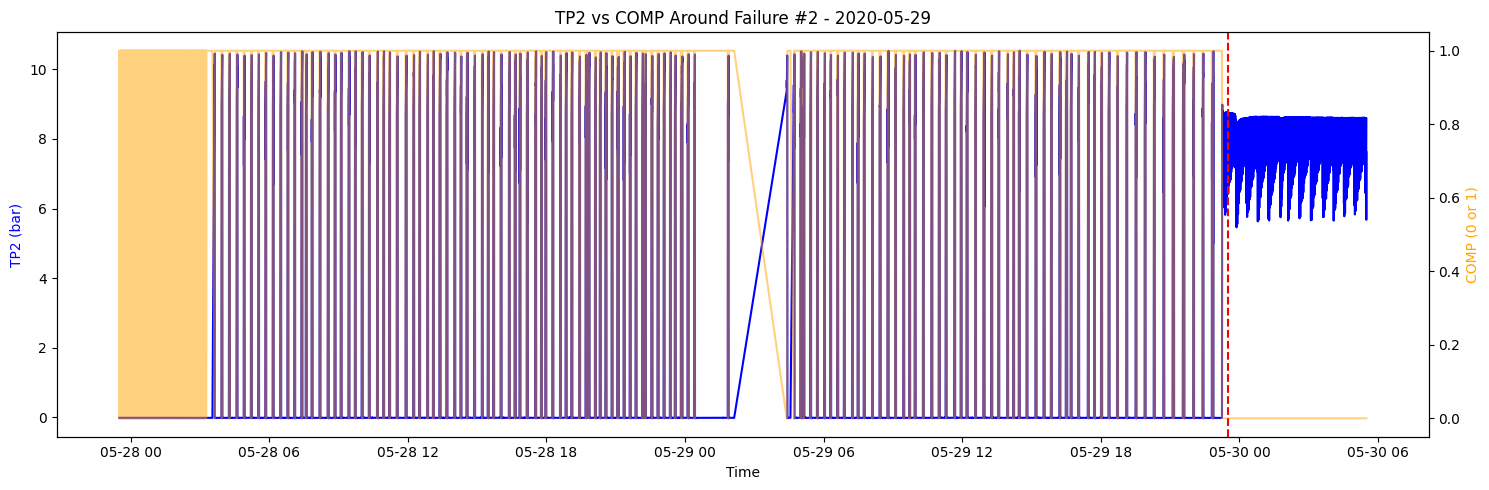

In [ ]:
# Same analysis as failure #1, applied to failure #2
failure_2_start = pd.to_datetime("2020-05-29 23:30:00")
window_start_2 = failure_2_start - pd.Timedelta(days=2)
window_end_2 = failure_2_start + pd.Timedelta(hours=6)

failure_2_window = df[
    (df['timestamp'] >= window_start_2) &
    (df['timestamp'] <= window_end_2)
]

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(failure_2_window['timestamp'], failure_2_window['TP2'], color='blue', label='TP2 (Pressure)')
ax1.set_xlabel('Time')
ax1.set_ylabel('TP2 (bar)', color='blue')

ax2 = ax1.twinx()
ax2.plot(failure_2_window['timestamp'], failure_2_window['COMP'], color='orange', alpha=0.5, label='COMP')
ax2.set_ylabel('COMP (0 or 1)', color='orange')

plt.axvline(x=failure_2_start, color='red', linestyle='--', label='Failure Start')
plt.title('TP2 vs COMP Around Failure #2 - 2020-05-29')
fig.tight_layout()
plt.show()

##Sensor Behavior Around Failure #3 (2020-06-05)

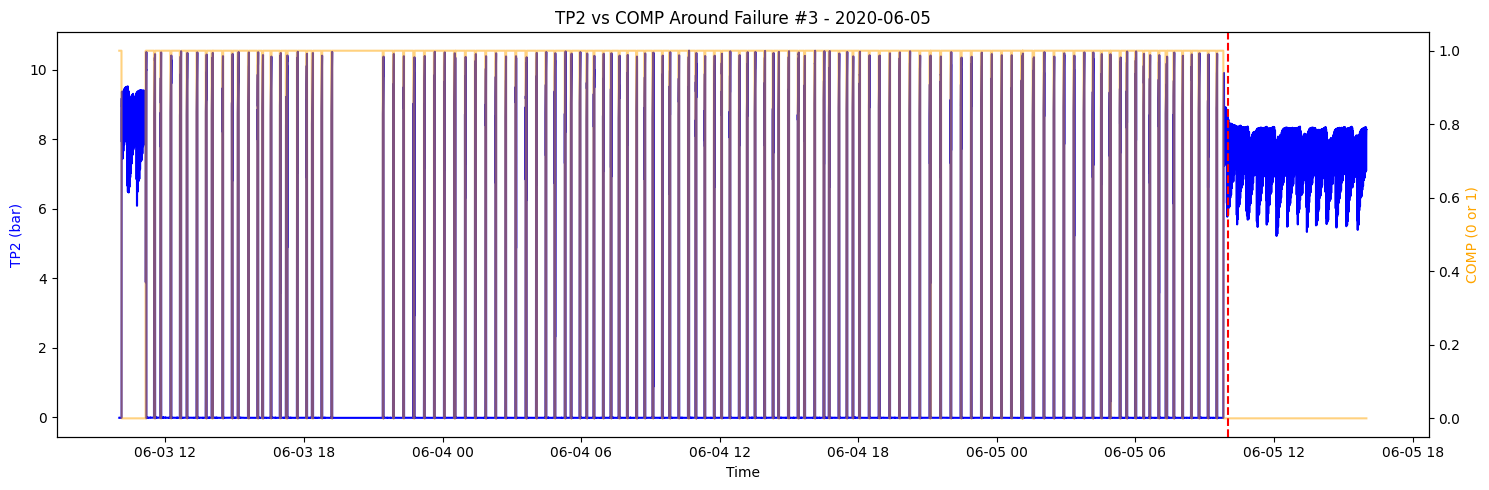

In [ ]:
# Same analysis, applied to failure #3
failure_3_start = pd.to_datetime("2020-06-05 10:00:00")
window_start_3 = failure_3_start - pd.Timedelta(days=2)
window_end_3 = failure_3_start + pd.Timedelta(hours=6)

failure_3_window = df[
    (df['timestamp'] >= window_start_3) &
    (df['timestamp'] <= window_end_3)
]

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(failure_3_window['timestamp'], failure_3_window['TP2'], color='blue', label='TP2 (Pressure)')
ax1.set_xlabel('Time')
ax1.set_ylabel('TP2 (bar)', color='blue')

ax2 = ax1.twinx()
ax2.plot(failure_3_window['timestamp'], failure_3_window['COMP'], color='orange', alpha=0.5, label='COMP')
ax2.set_ylabel('COMP (0 or 1)', color='orange')

plt.axvline(x=failure_3_start, color='red', linestyle='--', label='Failure Start')
plt.title('TP2 vs COMP Around Failure #3 - 2020-06-05')
fig.tight_layout()
plt.show()

## Overall Conclusion: TP2 Pattern is a Reliable Early-Warning Signal

The same pattern change was observed consistently across all 3 usable
failures (2020-04-18, 2020-05-29, 2020-06-05):

- Before failure: TP2 shows regular cycles reaching full pressure (~10 bar),
  with clear rest periods between cycles.
- After failure onset: pulse frequency increases noticeably, but TP2 no
  longer reaches the previous peak (~6-9 bar instead of ~10 bar).

This is consistent with the documented failure type (air leak) across all
3 events — not a coincidence. TP2 behavior is a strong candidate feature
for both anomaly detection and classification models.

Next step: extend this analysis to other pressure-related sensors
(TP3, H1, Reservoirs) to confirm whether the same pattern holds, before
moving to feature engineering.

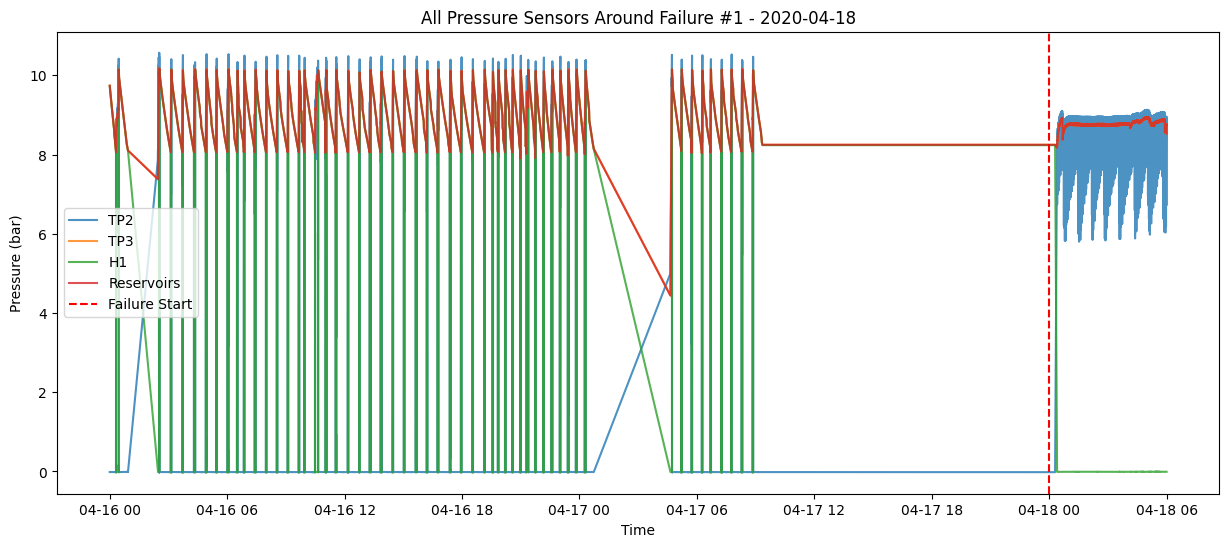

In [ ]:
# Compare all 4 pressure-related sensors around Failure #1
plt.figure(figsize=(15, 6))

plt.plot(failure_1_window['timestamp'], failure_1_window['TP2'], label='TP2', alpha=0.8)
plt.plot(failure_1_window['timestamp'], failure_1_window['TP3'], label='TP3', alpha=0.8)
plt.plot(failure_1_window['timestamp'], failure_1_window['H1'], label='H1', alpha=0.8)
plt.plot(failure_1_window['timestamp'], failure_1_window['Reservoirs'], label='Reservoirs', alpha=0.8)

plt.axvline(x=failure_1_start, color='red', linestyle='--', label='Failure Start')
plt.title('All Pressure Sensors Around Failure #1 - 2020-04-18')
plt.xlabel('Time')
plt.ylabel('Pressure (bar)')
plt.legend()
plt.show()

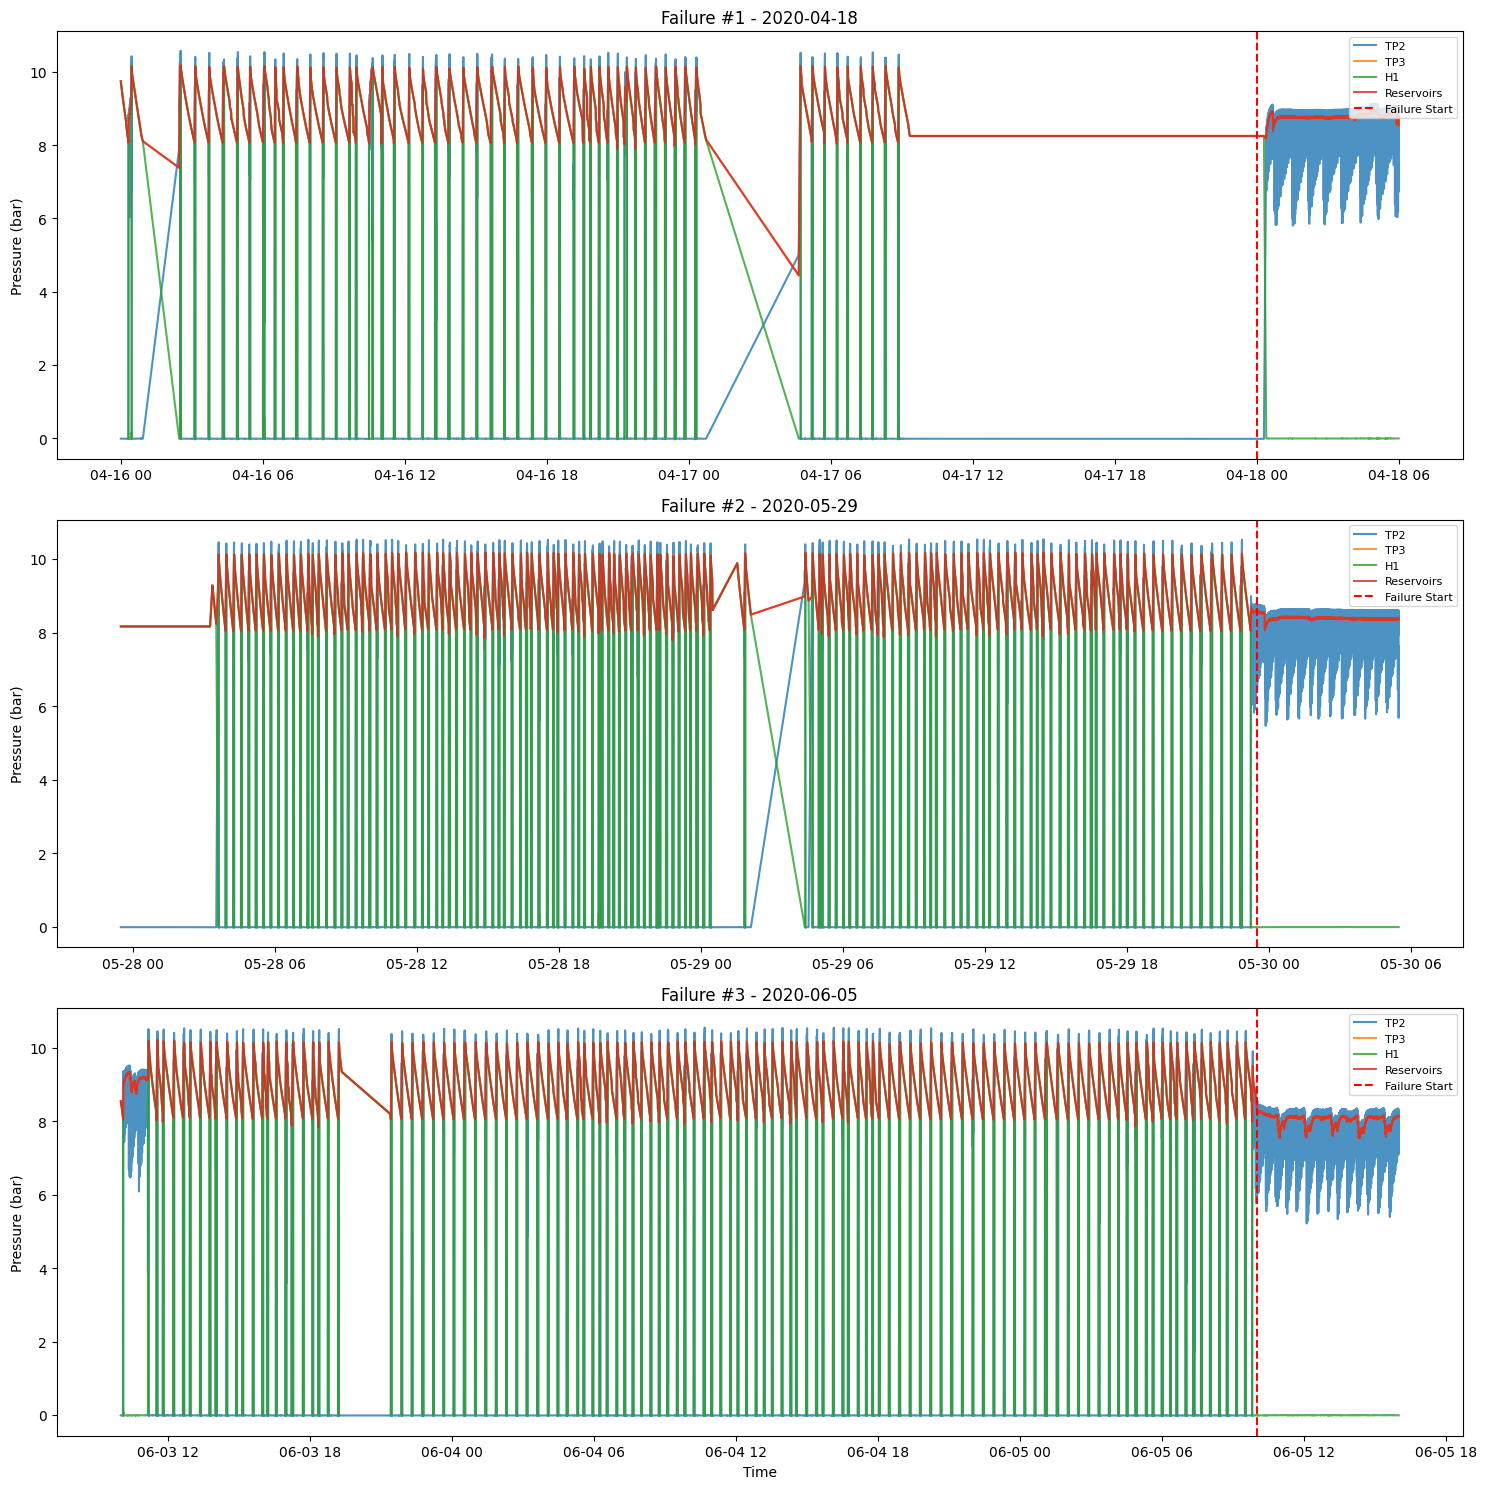

In [ ]:
# Create 3 subplots stacked vertically, one per failure
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

windows = [failure_1_window, failure_2_window, failure_3_window]
starts = [failure_1_start, failure_2_start, failure_3_start]
titles = ['Failure #1 - 2020-04-18', 'Failure #2 - 2020-05-29', 'Failure #3 - 2020-06-05']

# Loop through each failure and plot it in its own subplot
for i in range(3):
    ax = axes[i]
    window = windows[i]

    ax.plot(window['timestamp'], window['TP2'], label='TP2', alpha=0.8)
    ax.plot(window['timestamp'], window['TP3'], label='TP3', alpha=0.8)
    ax.plot(window['timestamp'], window['H1'], label='H1', alpha=0.8)
    ax.plot(window['timestamp'], window['Reservoirs'], label='Reservoirs', alpha=0.8)
    ax.axvline(x=starts[i], color='red', linestyle='--', label='Failure Start')

    ax.set_title(titles[i])
    ax.set_ylabel('Pressure (bar)')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time')
fig.tight_layout()
plt.show()

## Finding: Pressure Sensor Patterns Across All 3 Failures

- TP2 changes pattern after failure onset (faster pulses, lower peak) — confirmed across all 3 events
- H1 and TP3 go completely silent after failure onset — confirmed across all 3 events
- Reservoirs and TP3 stay elevated during normal rest periods (storage behavior), unlike TP2/H1

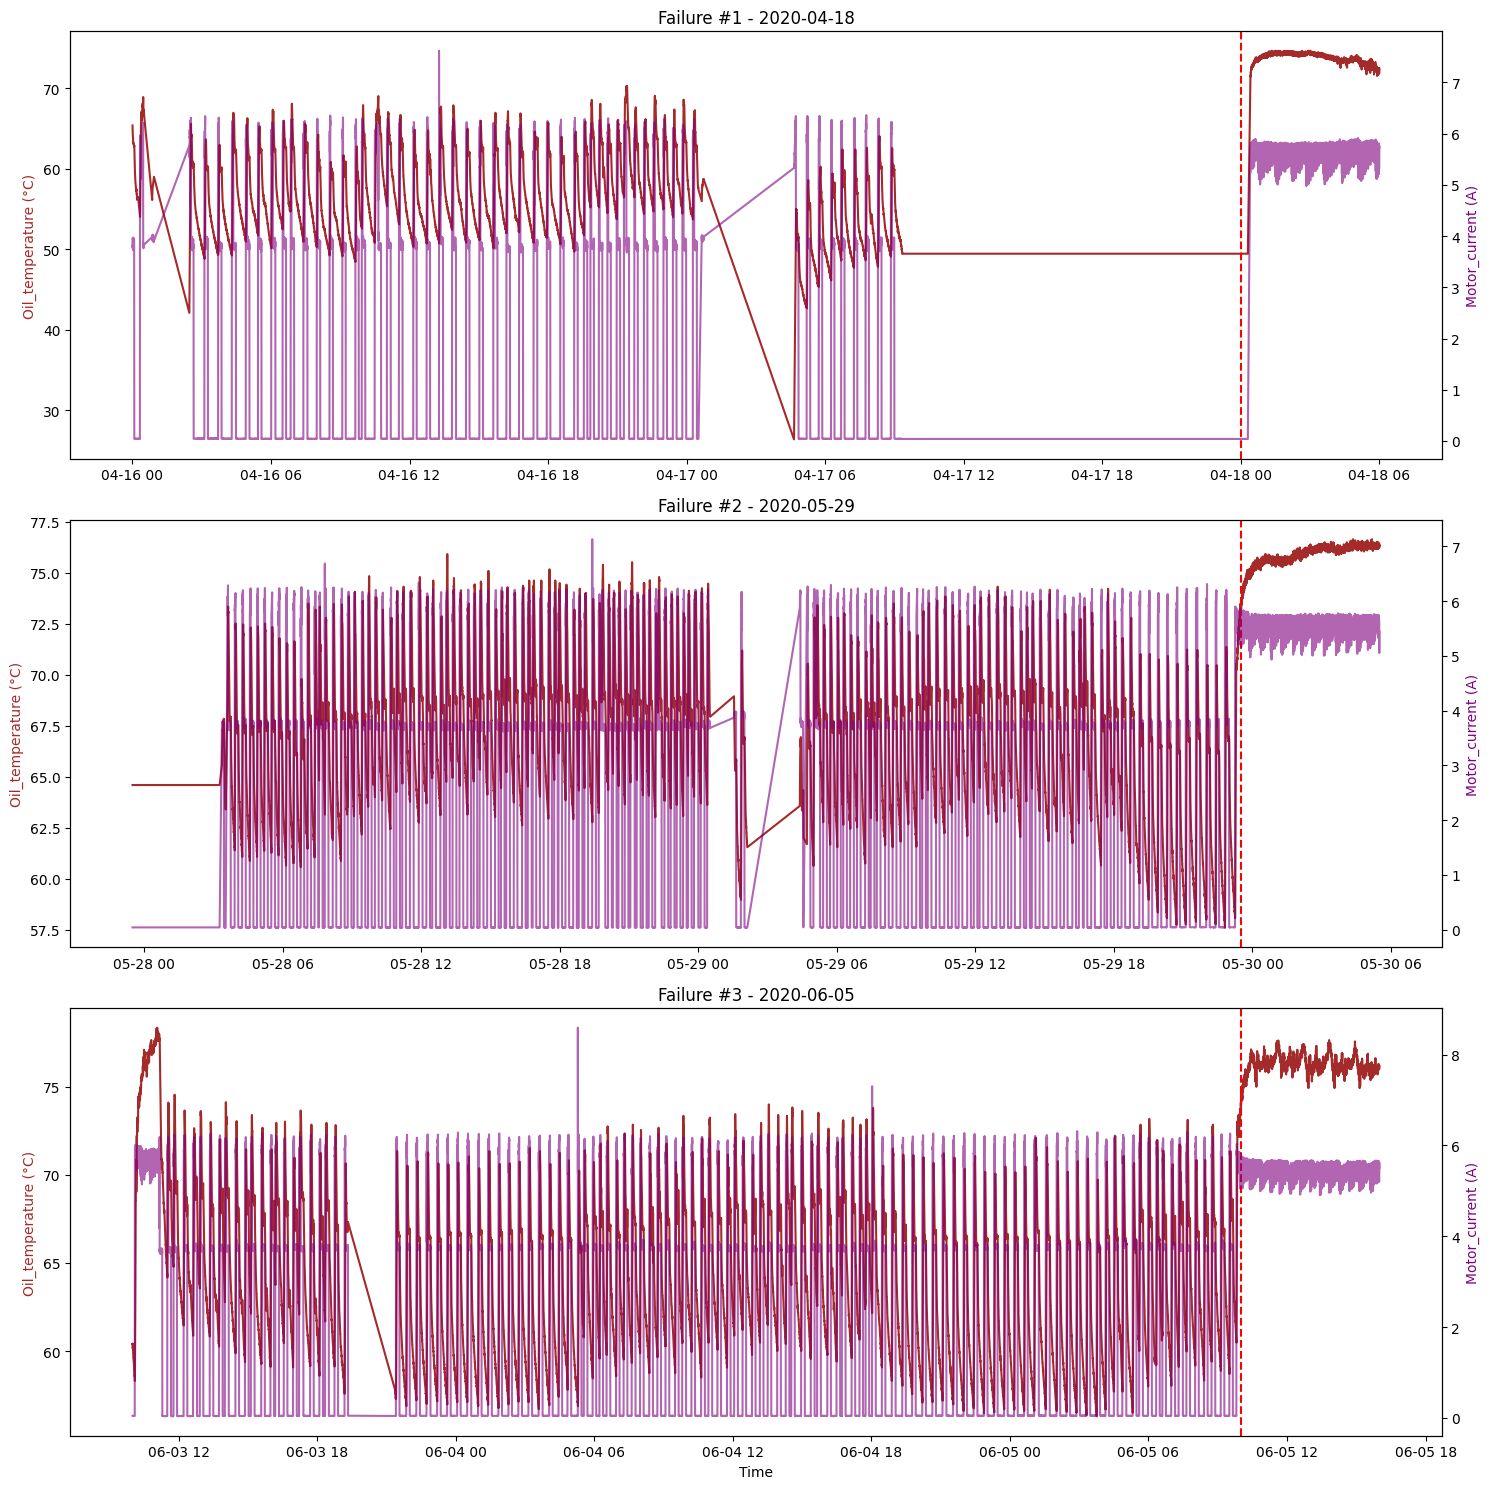

In [ ]:
# Compare Oil_temperature and Motor_current across all 3 failures
fig, axes = plt.subplots(3, 1, figsize=(15, 15))

for i in range(3):
    ax = axes[i]
    window = windows[i]

    # Plot Oil_temperature on the left axis
    ax.plot(window['timestamp'], window['Oil_temperature'], color='brown', label='Oil_temperature')
    ax.set_ylabel('Oil_temperature (°C)', color='brown')

    # Plot Motor_current on a second axis (different scale)
    ax2 = ax.twinx()
    ax2.plot(window['timestamp'], window['Motor_current'], color='purple', alpha=0.6, label='Motor_current')
    ax2.set_ylabel('Motor_current (A)', color='purple')

    ax.axvline(x=starts[i], color='red', linestyle='--', label='Failure Start')
    ax.set_title(titles[i])

axes[-1].set_xlabel('Time')
fig.tight_layout()
plt.show()

## Finding: Oil Temperature & Motor Current — Strongest Signal So Far

- After failure onset, Oil_temperature rises clearly and stays elevated
  (confirmed across all 3 failures)
- Motor_current shifts from intermittent pulsing to continuous steady
  operation (~5.5A) after failure onset — the compressor stops resting
  and runs constantly
- Physical explanation: to compensate for the air leak, the compressor
  works continuously instead of cycling on/off, generating more friction
  and heat
- This is the clearest and most stable signal found so far — a sustained
  level shift rather than just a pattern change, making it easier to
  detect reliably in a model